<a href="https://colab.research.google.com/github/johnjoseph004/AI-ML-internship/blob/main/day2_an.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
df=pd.read_csv('/content/boston.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


/tmp/ipykernel_2538/1317551543.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='rad',y='ptratio',palette='pastel')


Text(0.5, 1.0, 'Boxplot of age by tax')

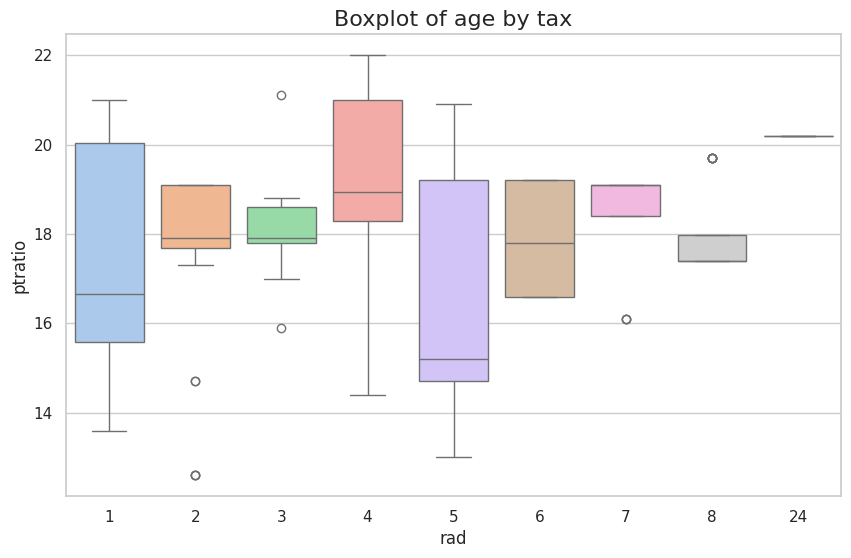

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x='rad',y='ptratio',palette='pastel')
plt.title('Boxplot of age by tax',fontsize=16)

/tmp/ipykernel_2538/3553702683.py:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=df,x='rad',y='ptratio',palette='pastel')


Text(0.5, 1.0, 'Boxplot of age by tax')

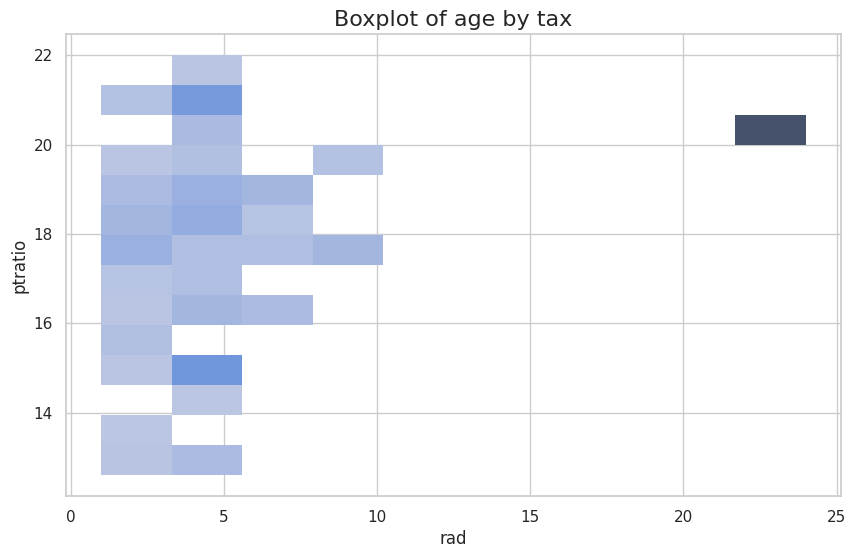

In [8]:
sns.set(style="whitegrid")
plt.figure(figsize=(10,6))
sns.histplot(data=df,x='rad',y='ptratio',palette='pastel')
plt.title('Boxplot of age by tax',fontsize=16)

In [6]:
from sklearn.preprocessing import MinMaxScaler,StandardScaler
numerical_columns=['age','ptratio']
df.dropna(subset=numerical_columns,inplace=True)

minmax_scaler=MinMaxScaler()
standard_scaler=StandardScaler()
df['age_MinMax']=minmax_scaler.fit_transform(df[['age']])
df['pt_MinMax']=minmax_scaler.fit_transform(df[['ptratio']])
df['age_Standard']=standard_scaler.fit_transform(df[['age']])
df['pt_Standard']=standard_scaler.fit_transform(df[['ptratio']])
df

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv,age_MinMax,pt_MinMax,age_Standard,pt_Standard
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0,0.641607,0.287234,-0.120013,-1.459000
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6,0.782698,0.553191,0.367166,-0.303094
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7,0.599382,0.553191,-0.265812,-0.303094
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4,0.441813,0.648936,-0.809889,0.113032
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2,0.528321,0.648936,-0.511180,0.113032
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4,0.681771,0.893617,0.018673,1.176466
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6,0.760041,0.893617,0.288933,1.176466
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9,0.907312,0.893617,0.797449,1.176466
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0,0.889804,0.893617,0.736996,1.176466


In [10]:

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

# Select only numerical columns for X to avoid the ValueError
X = df.select_dtypes(include=['number']).drop(columns=["medv"])
y=df["medv"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
model=LinearRegression()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
mse=mean_squared_error(y_test,y_pred)
r2=r2_score(y_test,y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5

print(f"R² Score: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R² Score: 0.6688
RMSE: 4.9286
